Fitting Continuous Model...
                            OLS Regression Results                            
Dep. Variable:                Log_Vol   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                 1.292e+04
Date:                Thu, 05 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:50:30   Log-Likelihood:                -826.92
No. Observations:                3468   AIC:                             1666.
Df Residuals:                    3462   BIC:                             1703.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

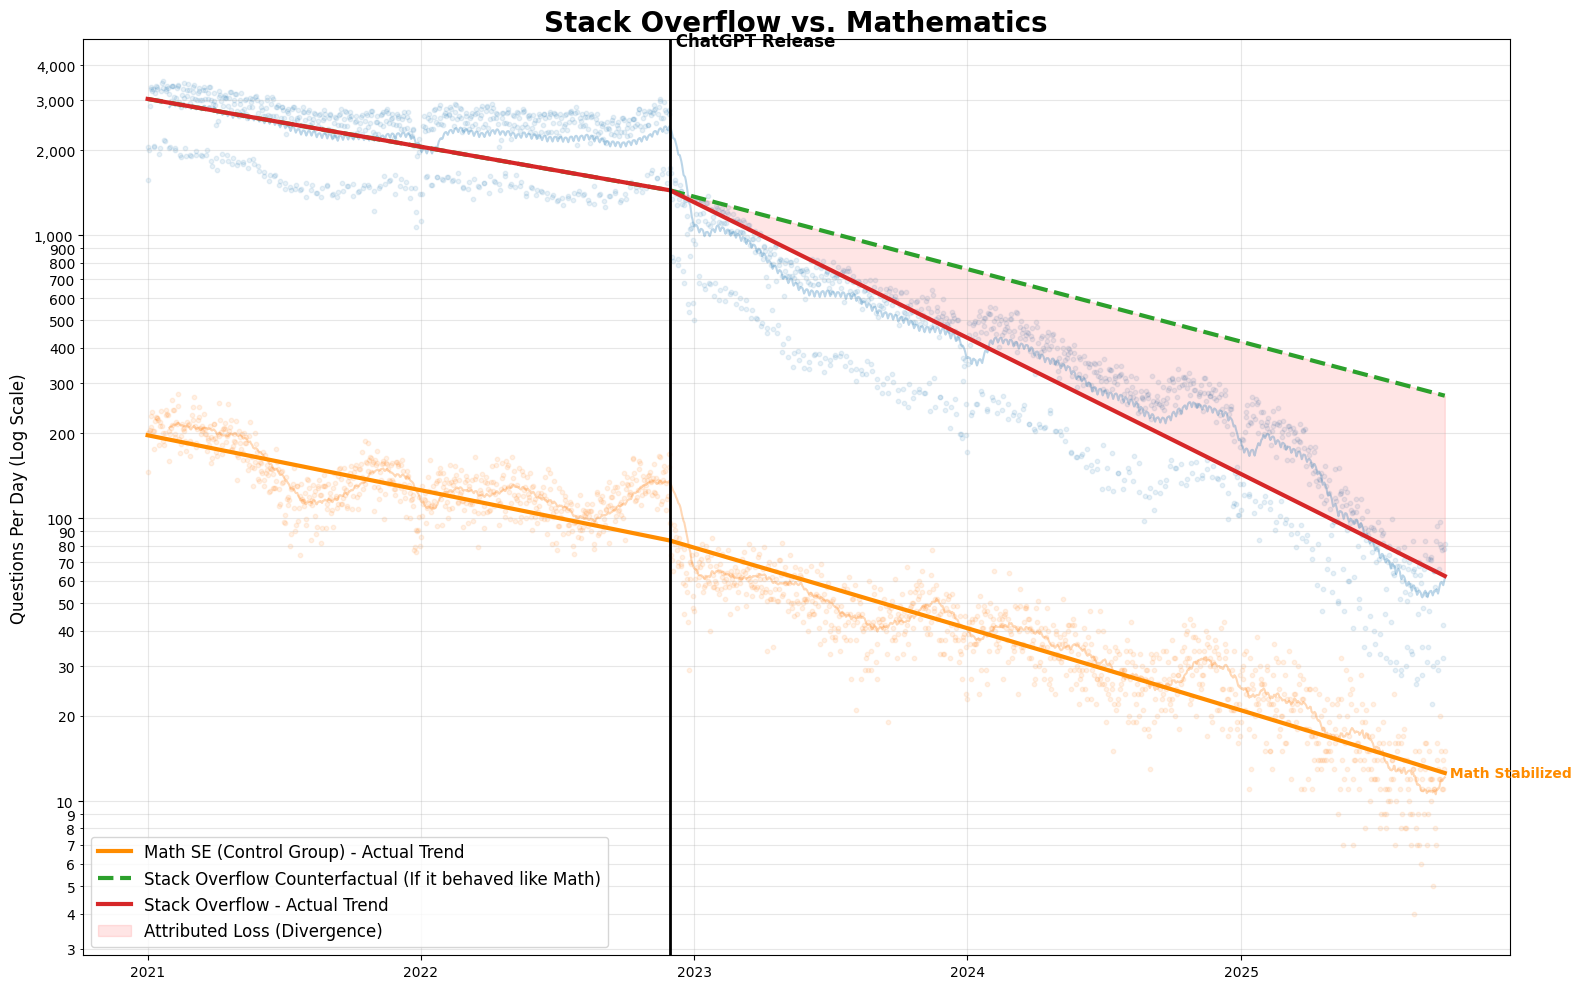

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def fit_and_plot_both_communities():
    # 1. LOAD DATA
    #SELECTED_USER = 'casual'
    #SELECTED_USER = 'regular'
    SELECTED_USER = 'super'
     # Options: 'Stack Overflow', 'Mathematics', 'Ask Ubuntu'
    match(SELECTED_USER):
        case 'new':
            files = {
                'Stack Overflow': 'Stack Overflow_Daily_New.csv',
                'Mathematics': 'Mathematics_Daily_New.csv'
            }
        case 'casual':
            files = {
                'Stack Overflow': 'Stack Overflow_Daily_Casual.csv',
                'Mathematics': 'Mathematics_Daily_Casual.csv'
            }
        case 'regular':
            files = {
                'Stack Overflow': 'Stack Overflow_Daily_Regular.csv',
                'Mathematics': 'Mathematics_Daily_Regular.csv'
            }
        case 'super':
            files = {
                'Stack Overflow': 'Stack Overflow_Daily_Super.csv',
                'Mathematics': 'Mathematics_Daily_Super.csv'
            }
        case _:
            files = {
                'Stack Overflow': 'Stack Overflow_Monolith_Daily_Extended_v2.csv',
                'Mathematics': 'Mathematics_Monolith_Daily_Extended_v2.csv'
            }
    
    dfs = []
    for name, path in files.items():
        try:
            d = pd.read_csv(path)
            d['Day'] = pd.to_datetime(d['Day'])
            d = d[d['Day'] >= '2021-01-01'].copy()
            d['Community'] = name
            dfs.append(d)
        except:
            continue
    df = pd.concat(dfs)
    
    # 2. CREATE VARIABLES (Centered Spline)
    treatment_date = pd.to_datetime('2022-11-30') # ChatGPT Launch
    #treatment_date = pd.to_datetime('2024-04-29') # optimal break point
    start_date = df['Day'].min()
    
    df['Time_Raw'] = (df['Day'] - start_date).dt.days
    launch_index = (treatment_date - start_date).days
    df['Time_Years'] = (df['Time_Raw'] - launch_index) / 365.0
    df['Post_Time'] = np.where(df['Day'] >= treatment_date, 1, 0)
    
    # The "Kink" Variable (0 before launch, counts up after)
    df['Time_Post_Trend'] = df['Time_Years'] * df['Post_Time']
    
    df['Log_Vol'] = np.log(df['Total_Questions'] + 1)
    
    # 3. FIT MODEL
    print("Fitting Continuous Model...")
    formula = "Log_Vol ~ C(Community) + C(Community):Time_Years + C(Community):Time_Post_Trend"
    model = smf.ols(formula, data=df).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
    print(model.summary())
    
    # 4. PREPARE PLOTTING DATA
    
    # --- A. Stack Overflow Data ---
    so_df = df[df['Community'] == 'Stack Overflow'].copy().sort_values('Day')
    so_fitted_log = model.predict(so_df)
    
    # SO Counterfactual (Using Math's slope change)
    params = model.params
    math_slope_change = params['C(Community)[Mathematics]:Time_Post_Trend']
    so_intercept = params['C(Community)[T.Stack Overflow]'] + params['Intercept']
    so_pre_slope = params['C(Community)[Stack Overflow]:Time_Years']
    
    so_counterfactual_log = (so_intercept + 
                             (so_pre_slope * so_df['Time_Years']) + 
                             (math_slope_change * so_df['Time_Post_Trend']))
    
    so_df['Fitted_Count'] = np.exp(so_fitted_log) - 1
    so_df['Counterfactual_Count'] = np.exp(so_counterfactual_log) - 1
    so_df['Smoothed_Count'] = so_df['Total_Questions'].rolling(30).mean()
    
    # --- B. Mathematics Data ---
    math_df = df[df['Community'] == 'Mathematics'].copy().sort_values('Day')
    math_fitted_log = model.predict(math_df)
    
    math_df['Fitted_Count'] = np.exp(math_fitted_log) - 1
    math_df['Smoothed_Count'] = math_df['Total_Questions'].rolling(30).mean()
    
    # 5. PLOT
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # --- Plot Mathematics (Control) ---
    # Raw Data (Gray/Orange)
    ax.scatter(math_df['Day'], math_df['Total_Questions'], color='tab:orange', alpha=0.1, s=10)
    # Moving Avg
    ax.plot(math_df['Day'], math_df['Smoothed_Count'], color='tab:orange', linewidth=1.5, alpha=0.3)
    # Fitted Line (Solid Orange)
    ax.plot(math_df['Day'], math_df['Fitted_Count'], color='darkorange', linewidth=3, label='Math SE (Control Group) - Actual Trend')
    
    # --- Plot Stack Overflow (Treated) ---
    # Raw Data (Blue)
    ax.scatter(so_df['Day'], so_df['Total_Questions'], color='tab:blue', alpha=0.1, s=10)
    # Moving Avg
    ax.plot(so_df['Day'], so_df['Smoothed_Count'], color='tab:blue', linewidth=1.5, alpha=0.3)
    
    # Counterfactual (Green Dashed) - Should look parallel to Math in post-period
    ax.plot(so_df['Day'], so_df['Counterfactual_Count'], color='tab:green', linestyle='--', linewidth=3, label='Stack Overflow Counterfactual (If it behaved like Math)')
    
    # Fitted Line (Red)
    ax.plot(so_df['Day'], so_df['Fitted_Count'], color='tab:red', linewidth=3, label='Stack Overflow - Actual Trend')
    
    # Highlight Gap
    ax.fill_between(so_df['Day'], so_df['Fitted_Count'], so_df['Counterfactual_Count'], 
                    where=(so_df['Day'] >= treatment_date),
                    color='red', alpha=0.1, label='Attributed Loss (Divergence)')
    
    # Styling
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:,.0f}'.format(y)))
    ax.yaxis.set_minor_formatter(ticker.FuncFormatter(lambda y, _: '{:,.0f}'.format(y)))
    
    ax.set_title('Stack Overflow vs. Mathematics', fontsize=20, fontweight='bold')
    ax.set_ylabel('Questions Per Day (Log Scale)', fontsize=12)
    
    ax.axvline(treatment_date, color='black', linewidth=2)
    ax.text(treatment_date, ax.get_ylim()[1]*0.95, ' ChatGPT Release', ha='left', fontsize=12, fontweight='bold')
    
    # Add text annotation pointing to Math's stability
    last_day = math_df['Day'].max()
    last_math_val = math_df['Fitted_Count'].iloc[-1]
    ax.text(last_day, last_math_val, ' Math Stabilized', color='darkorange', fontweight='bold', va='center')
    
    ax.legend(loc='lower left', frameon=True, fontsize=12)
    ax.grid(True, alpha=0.3, which="both")
    
    plt.tight_layout()
    plt.show()

fit_and_plot_both_communities()